In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import export_text

In [2]:
# Load the iris dataset for building DT
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
x = iris.data[:,:2]
y = iris.target
# Normally we use all 4 features, but here we take only 2 so that we can visualize the split.

In [5]:
pd.DataFrame(x).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [6]:
pd.DataFrame(y).value_counts()

0
0    50
1    50
2    50
Name: count, dtype: int64

# Perfectly balanced dataset.
# Decision Trees behave well when classes are balanced.

# Statistical Summary

In [7]:

pd.DataFrame(x).describe()

,0,1
count,150.000000,150.000000
mean,5.843333,3.057333
std,0.828066,0.435866
min,4.300000,2.000000
25%,5.100000,2.800000
50%,5.800000,3.000000
75%,6.400000,3.300000
max,7.900000,4.400000


# split the data into training and test for builiding DT model and for prediction

In [8]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(x_train, y_train)
# Depth = number of splits

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# predict

In [10]:

y_pred_train = dt_clf.predict(x_train)
y_pred_test = dt_clf.predict(x_test)

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [12]:
confusion_matrix(y_test, y_pred_test)

array([[14,  1,  0],
       [ 0,  7,  4],
       [ 0,  4,  8]], dtype=int64)

In [13]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.58      0.64      0.61        11
           2       0.67      0.67      0.67        12

    accuracy                           0.76        38
   macro avg       0.75      0.75      0.75        38
weighted avg       0.77      0.76      0.77        38



In [14]:
# precision → false positive control
# recall → false negative control

In [15]:
print(accuracy_score(y_train, y_pred_train))
print()
print(accuracy_score(y_test, y_pred_test))

# This allows overfitting check.

0.8214285714285714

0.7631578947368421


In [16]:
dt_clf = DecisionTreeClassifier(max_depth=3)
dt_clf.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred_train = dt_clf.predict(x_train)
y_pred_test = dt_clf.predict(x_test)


In [18]:
print(accuracy_score(y_train, y_pred_train))
print()
print(accuracy_score(y_test, y_pred_test))

0.8214285714285714

0.7631578947368421


# plot the decisionTree Classifier

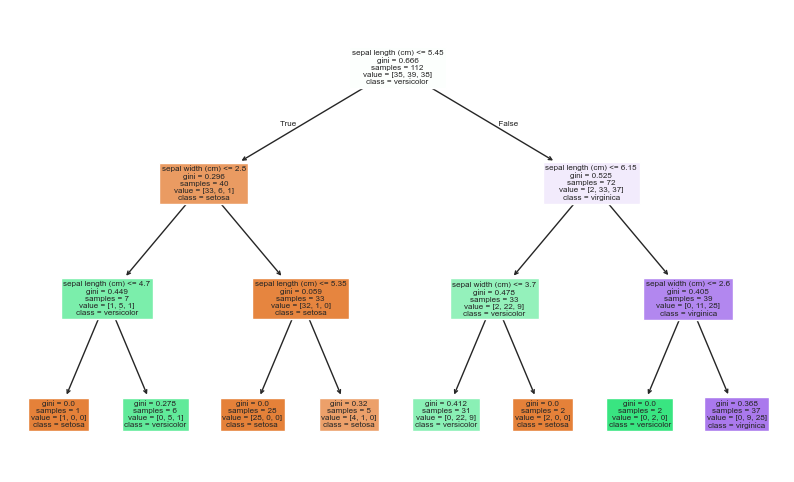

In [19]:
from sklearn.tree import plot_tree
from sklearn.tree import export_text
plt.figure(figsize=(10,6))
plot_tree(dt_clf, filled=True, feature_names=iris.feature_names[:2], 
          class_names=iris.target_names)
plt.show()


# Step 1 — Original Data (No Split)
- Here the model has not learned anything yet.

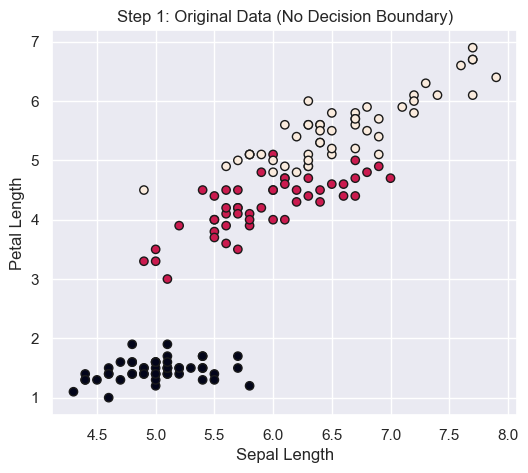

In [20]:
X = iris.data[:, [0, 2]]   # Sepal Length and Petal Length
y = iris.target
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Step 1: Original Data (No Decision Boundary)")
plt.show()


# Step 2 — First Split (Root Node)

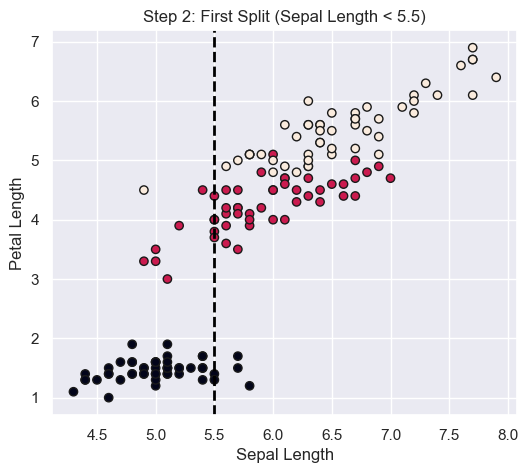

In [21]:
# SL < 5.5
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')

plt.axvline(x=5.5, linestyle='--', color='black', linewidth=2)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Step 2: First Split (Sepal Length < 5.5)")
plt.show()

# Step 3 — Second Split

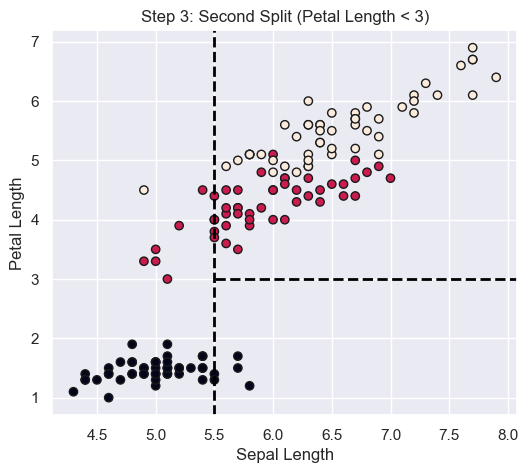

In [22]:
# Petal Length < 3
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')

plt.axvline(x=5.5, linestyle='--', color='black', linewidth=2)
plt.axhline(y=3, xmin=0.35, linestyle='--', color='black', linewidth=2)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Step 3: Second Split (Petal Length < 3)")
plt.show()

In [23]:
Tree_Rule = export_text(dt_clf, feature_names=['sepal_length', 'sepal_width'])
print(Tree_Rule)

|--- sepal_length <= 5.45
|   |--- sepal_width <= 2.80
|   |   |--- sepal_length <= 4.70
|   |   |   |--- class: 0
|   |   |--- sepal_length >  4.70
|   |   |   |--- class: 1
|   |--- sepal_width >  2.80
|   |   |--- sepal_length <= 5.35
|   |   |   |--- class: 0
|   |   |--- sepal_length >  5.35
|   |   |   |--- class: 0
|--- sepal_length >  5.45
|   |--- sepal_length <= 6.15
|   |   |--- sepal_width <= 3.70
|   |   |   |--- class: 1
|   |   |--- sepal_width >  3.70
|   |   |   |--- class: 0
|   |--- sepal_length >  6.15
|   |   |--- sepal_width <= 2.60
|   |   |   |--- class: 1
|   |   |--- sepal_width >  2.60
|   |   |   |--- class: 2



# Decision Tree Classification Project – Penguins Dataset

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import export_text

In [25]:
df = pd.read_csv('MulticlassClassificationDataset.csv')
df.head()

,studyName,Sample Number,Species,Island,Individual ID,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A1,11/11/2007,39.1,18.7,181,.,MALE,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A2,11/11/2007,39.5,17.4,186,3800,FEMALE,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A1,11/16/2007,40.3,18.0,.,3250,FEMALE,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A2,11/16/2007,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Torgersen,N3A1,11/16/2007,36.7,19.3,193,3450,FEMALE,NaN


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Island               344 non-null    object 
 4   Individual ID        344 non-null    object 
 5   Date Egg             344 non-null    object 
 6   Culmen Length (mm)   342 non-null    float64
 7   Culmen Depth (mm)    342 non-null    float64
 8   Flipper Length (mm)  342 non-null    object 
 9   Body Mass (g)        342 non-null    object 
 10  Sex                  334 non-null    object 
 11  Comments             26 non-null     object 
dtypes: float64(2), int64(1), object(9)
memory usage: 32.4+ KB


In [27]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Island', 'Individual ID',
       'Date Egg', 'Culmen Length (mm)', 'Culmen Depth (mm)',
       'Flipper Length (mm)', 'Body Mass (g)', 'Sex', 'Comments'],
      dtype='object')

In [28]:
# dropping non-significant vvariable
df.drop(['studyName','Sample Number','Individual ID', 'Date Egg','Comments'], axis=1, inplace=True)

# Reason to Drop
| Column        | Reason                              |
| ------------- | ----------------------------------- |
| studyName     | Same for most rows                  |
| Sample Number | Just row number                     |
| Individual ID | Unique identifier                   |
| Date Egg      | Not relevant for species prediction |
| Comments      | Mostly missing values               |



In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Culmen Length (mm)   342 non-null    float64
 3   Culmen Depth (mm)    342 non-null    float64
 4   Flipper Length (mm)  342 non-null    object 
 5   Body Mass (g)        342 non-null    object 
 6   Sex                  334 non-null    object 
dtypes: float64(2), object(5)
memory usage: 18.9+ KB


In [30]:
df['Flipper Length (mm)'] = pd.to_numeric(df['Flipper Length (mm)'], errors='coerce')
df['Body Mass (g)'] = pd.to_numeric(df['Body Mass (g)'], errors='coerce')

In [31]:
df.isnull().sum()

Species                 0
Island                  0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     3
Body Mass (g)           3
Sex                    10
dtype: int64

In [32]:
for i in df.columns:
    print("******************************", i ,"************************************")
    print()
    print(set(df[i].value_counts()))
    print()

****************************** Species ************************************

{152, 124, 68}

****************************** Island ************************************

{168, 124, 52}

****************************** Culmen Length (mm) ************************************

{1, 2, 3, 4, 5, 6, 7}

****************************** Culmen Depth (mm) ************************************

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12}

****************************** Flipper Length (mm) ************************************

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 22}

****************************** Body Mass (g) ************************************

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}

****************************** Sex ************************************

{168, 1, 165}



In [33]:
for i in df.columns:
    print("******************************", i ,"************************************")
    print()
    print(set(df[i].unique()))
    print()

****************************** Species ************************************

{'Gentoo penguin (Pygoscelis papua)', 'Adelie Penguin (Pygoscelis adeliae)', 'Chinstrap penguin (Pygoscelis antarctica)'}

****************************** Island ************************************

{'Torgersen', 'Biscoe', 'Dream'}

****************************** Culmen Length (mm) ************************************

{49.4, 49.9, 45.7, 50.4, 32.1, 33.1, 33.5, 35.1, 36.2, 35.6, 38.1, 35.7, 40.2, 41.5, 35.2, 34.1, 36.7, 37.8, 38.7, 38.9, 39.5, 40.3, 42.0, 42.5, 46.0, 44.1, 45.8, 46.5, 50.0, 51.3, 52.7, 51.7, 52.0, 58.0, 54.2, 55.8, 59.6, 47.7, 47.2, 44.0, 48.2, 45.0, 50.2, 43.8, 34.6, 34.4, 34.5, 34.0, 35.9, 35.3, 35.0, 35.5, 36.6, 36.4, 36.5, 36.0, 36.9, 37.7, 37.9, 37.2, 37.6, 37.0, 38.6, 38.2, 38.8, 37.5, 37.3, 39.1, 39.3, 39.2, 39.8, 39.6, 39.0, 39.7, 40.6, 40.5, 40.9, 41.1, 40.8, 40.1, 41.4, 41.3, 41.6, 41.8, 41.0, 42.2, 42.3, 42.8, 42.1, 42.9, 43.2, 42.7, 43.1, 43.5, 43.3, 44.5, 44.4, 45.6, 45.4, 45.2, 4

In [34]:
num_cols = ['Culmen Length (mm)','Culmen Depth (mm)',
            'Flipper Length (mm)','Body Mass (g)']


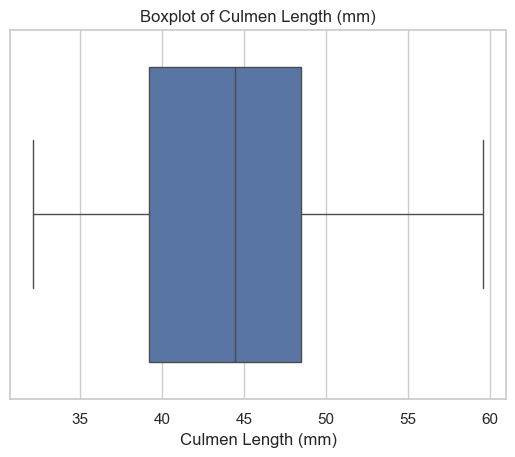

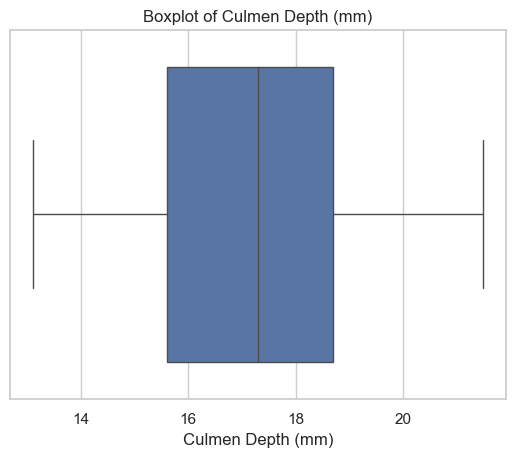

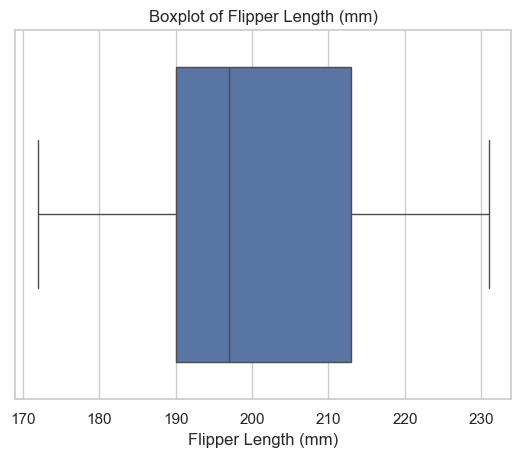

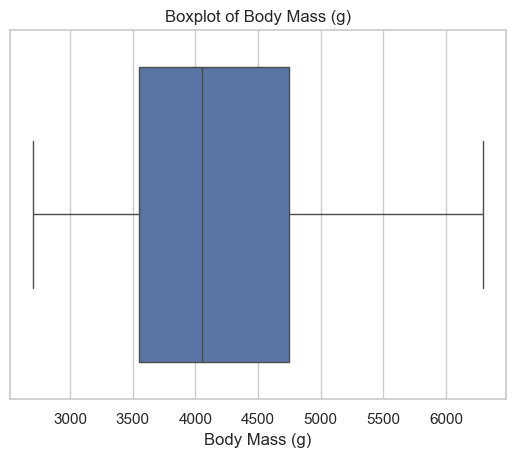

In [35]:
def boxplots(col):
    sns.boxplot(x = df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
num_cols_1 = df.select_dtypes(include=np.number).columns    
for i in num_cols:
    boxplots(i)

In [36]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [37]:
df.isnull().sum()

Species                 0
Island                  0
Culmen Length (mm)      0
Culmen Depth (mm)       0
Flipper Length (mm)     0
Body Mass (g)           0
Sex                    10
dtype: int64

In [38]:
df['Sex'].value_counts()

Sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [39]:
df['Sex'].replace('.', np.nan, inplace=True)

In [40]:
df['Sex'].fillna(df['Sex'].mode()[0], inplace=True)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Culmen Length (mm)   344 non-null    float64
 3   Culmen Depth (mm)    344 non-null    float64
 4   Flipper Length (mm)  344 non-null    float64
 5   Body Mass (g)        344 non-null    float64
 6   Sex                  344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [42]:
df.isnull().sum()

Species                0
Island                 0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
dtype: int64

In [43]:
# Dependent variable - only label encoding required - Species
df['Species'] = df['Species'].astype('category')
df['Species'] = df['Species'].cat.codes


In [44]:
df['Species'].value_counts()
# Z test
# T test

Species
0    152
2    124
1     68
Name: count, dtype: int64

In [45]:
df['Species'].unique()
# Attention All you need
# RNN  for sequential data--> lstm
# Attention ---> GenAI ---> transformer--> Attention scrore= softmax(Q.K/sqrt of embdedding dimension).value

array([0, 1, 2], dtype=int8)

In [46]:
df['Island'].value_counts()

Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [47]:
df = pd.get_dummies(df, columns=['Island', 'Sex'], drop_first=True)

In [48]:
df.head()

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Island_Dream,Island_Torgersen,Sex_MALE
0,0,39.10000,18.70000,181.000000,4203.079179,False,True,True
1,0,39.50000,17.40000,186.000000,3800.000000,False,True,False
2,0,40.30000,18.00000,200.932551,3250.000000,False,True,False
3,0,43.92193,17.15117,200.932551,4203.079179,False,True,True
4,0,36.70000,19.30000,193.000000,3450.000000,False,True,False


In [49]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Species,344.0,NaN,NaN,NaN,0.918605,0.89332,0.0,0.0,1.0,2.0,2.0
Culmen Length (mm),344.0,NaN,NaN,NaN,43.92193,5.443643,32.1,39.275,44.25,48.5,59.6
Culmen Depth (mm),344.0,NaN,NaN,NaN,17.15117,1.969027,13.1,15.6,17.3,18.7,21.5
Flipper Length (mm),344.0,NaN,NaN,NaN,200.932551,14.017008,172.0,190.0,197.0,213.0,231.0
Body Mass (g),344.0,NaN,NaN,NaN,4203.079179,799.23983,2700.0,3550.0,4050.0,4750.0,6300.0
Island_Dream,344,2,False,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Island_Torgersen,344,2,False,292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex_MALE,344,2,True,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of Male : 179
Number of Female : 165


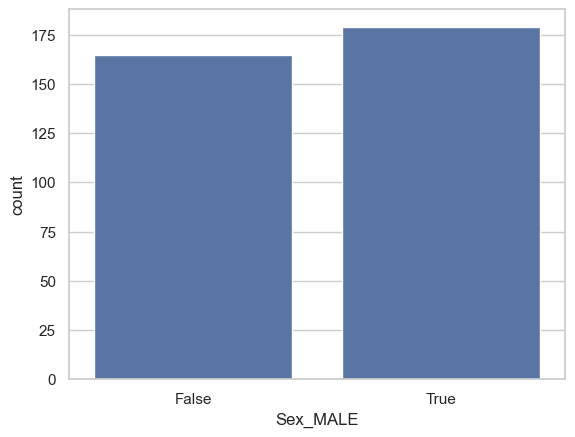

In [50]:
sns.countplot(data=df, x='Sex_MALE')
Male, Female = df['Sex_MALE'].value_counts()
print("Number of Male :", Male)
print("Number of Female :", Female)
plt.show()

Number of A : 152
Number of B : 124
Number of C: 68


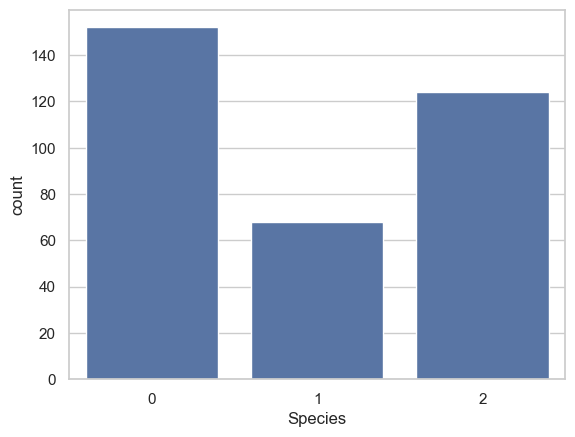

In [51]:
# imbalance check
sns.countplot(data=df, x='Species')
A, B, C = df['Species'].value_counts()
print("Number of A :", A)
print("Number of B :",B)
print("Number of C:", C)
plt.show()

In [52]:
df.columns

Index(['Species', 'Culmen Length (mm)', 'Culmen Depth (mm)',
       'Flipper Length (mm)', 'Body Mass (g)', 'Island_Dream',
       'Island_Torgersen', 'Sex_MALE'],
      dtype='object')

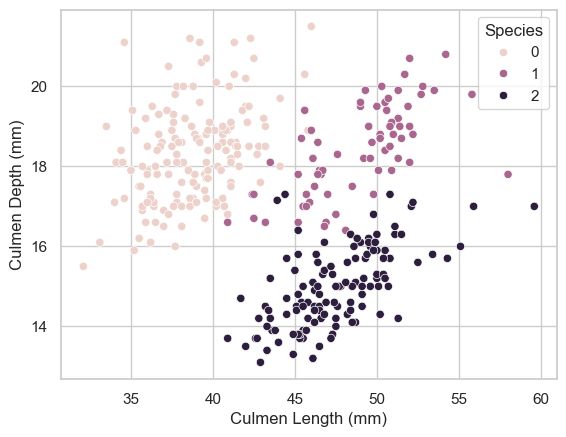

In [53]:
sns.scatterplot(x='Culmen Length (mm)', y ='Culmen Depth (mm)', data=df, hue='Species')
plt.show()

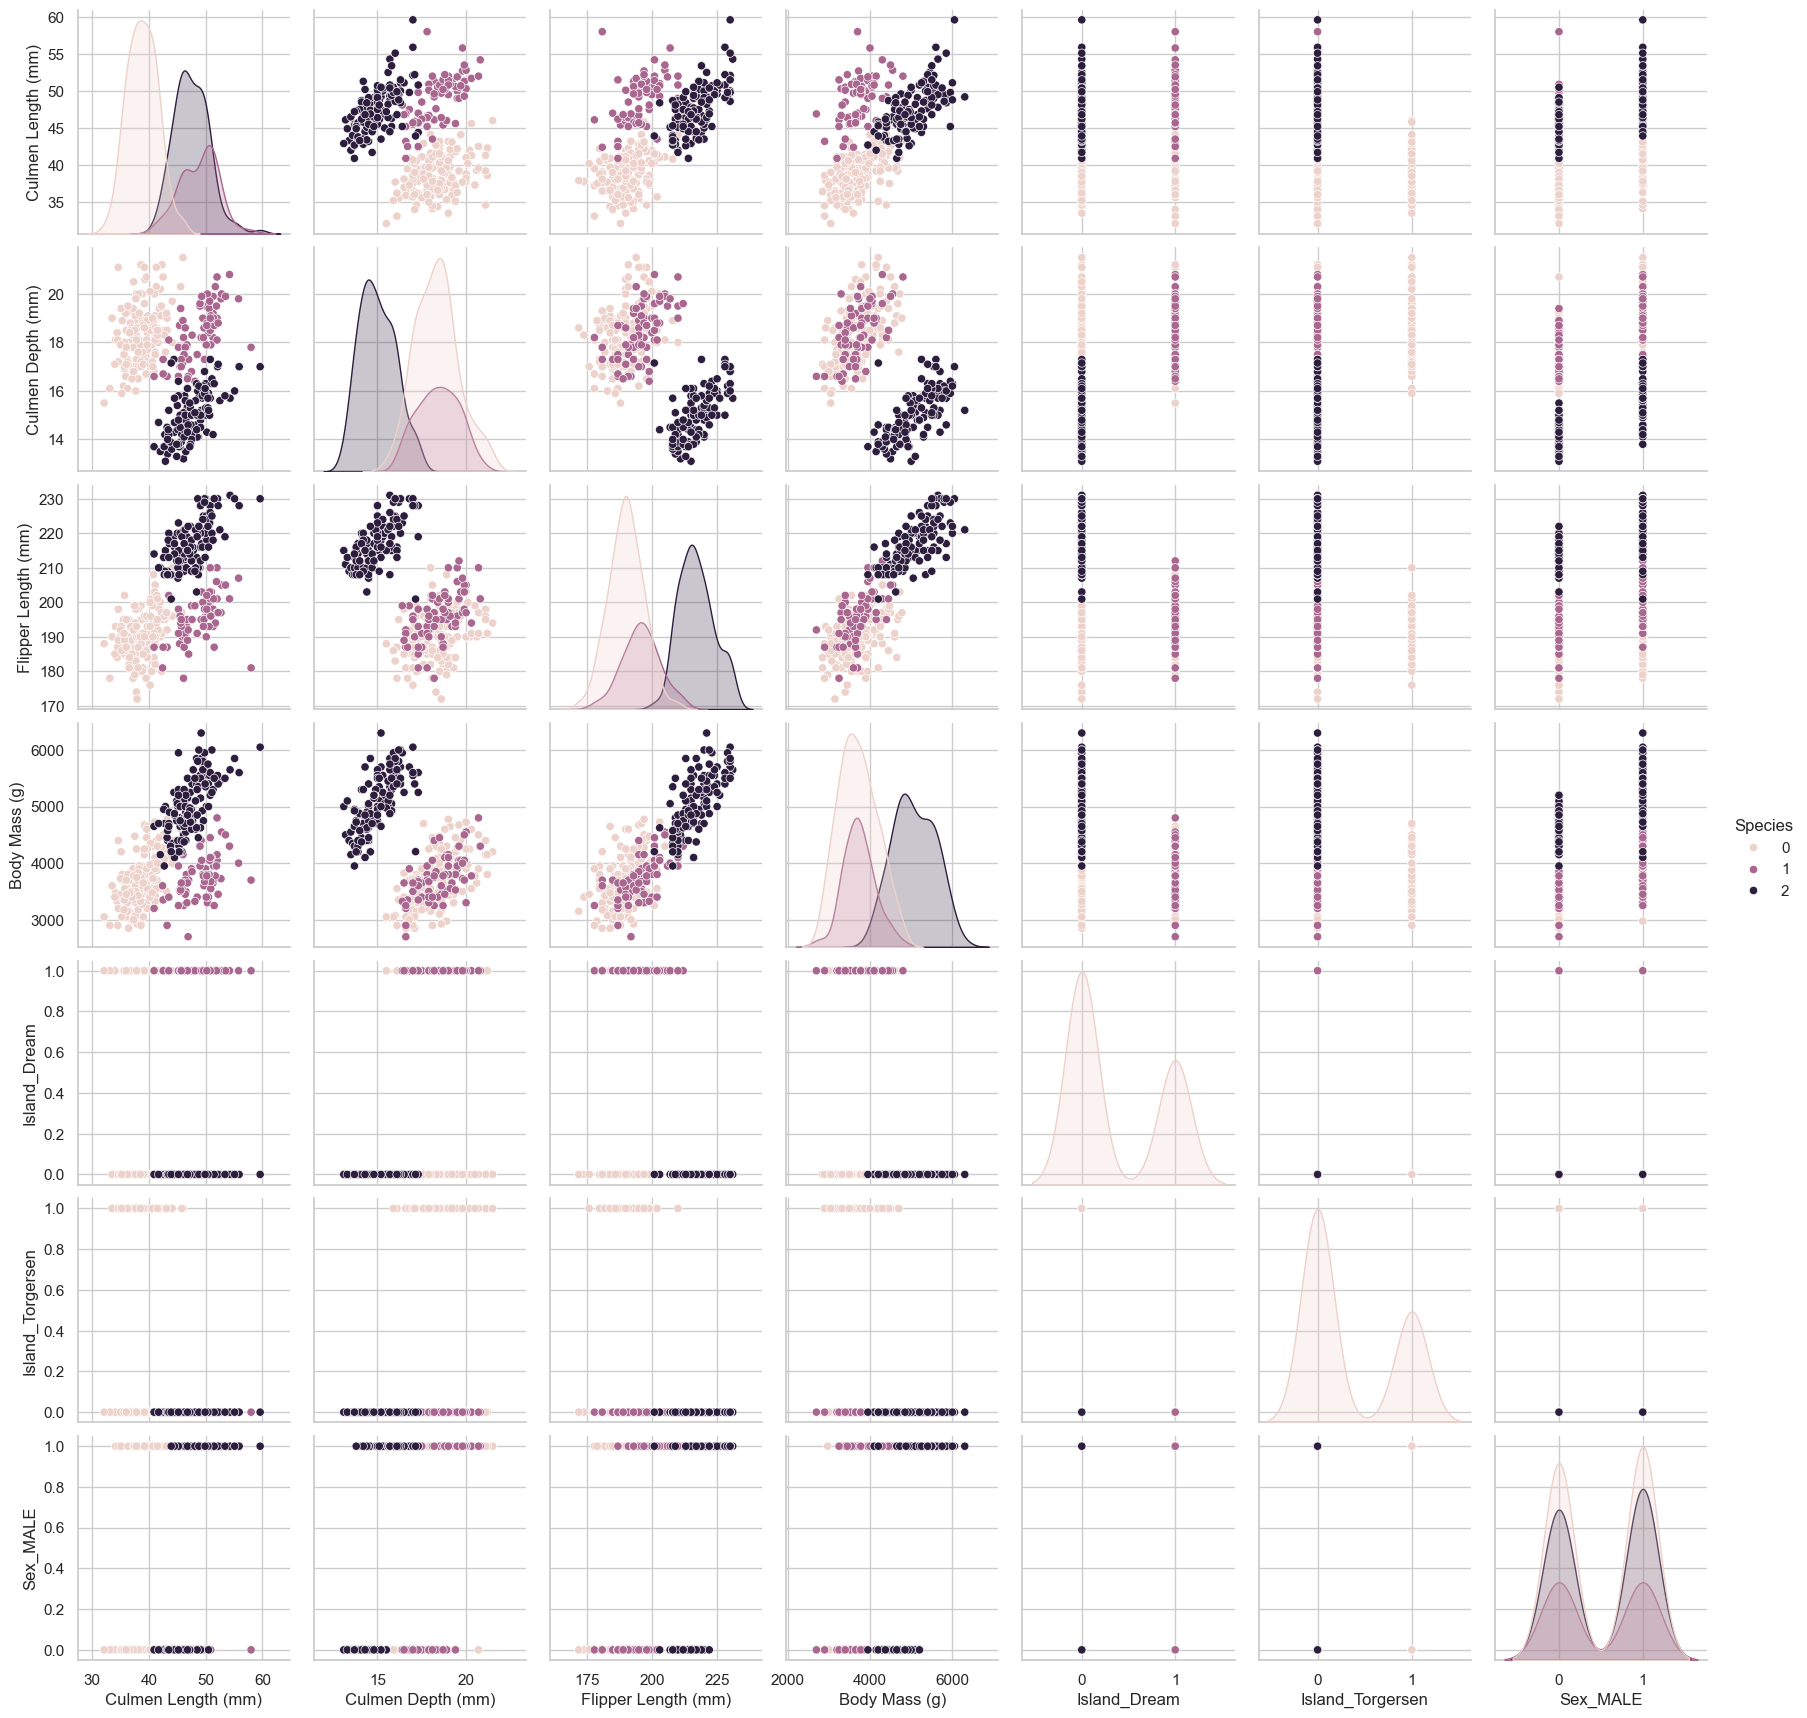

In [54]:
sns.pairplot(data=df, hue='Species')
plt.show()

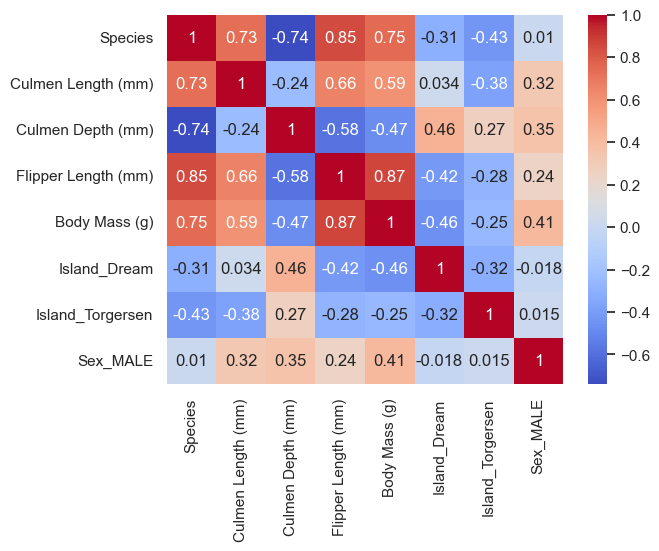

In [55]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()
# Decision Trees do NOT require correlation removal

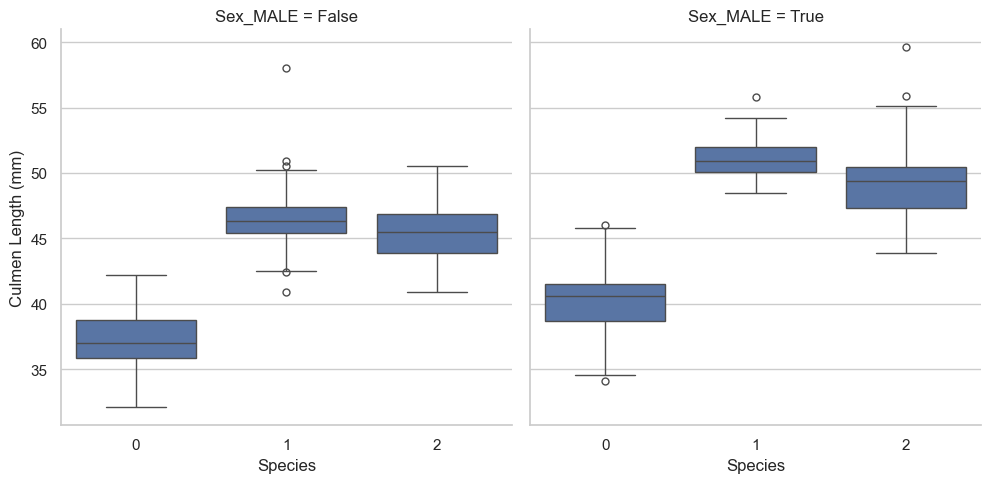

In [56]:
sns.catplot(data=df, x ='Species', y ='Culmen Length (mm)', kind='box', col = 'Sex_MALE')
plt.show()

In [57]:
# Split the data into training and test
df.head()

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Island_Dream,Island_Torgersen,Sex_MALE
0,0,39.10000,18.70000,181.000000,4203.079179,False,True,True
1,0,39.50000,17.40000,186.000000,3800.000000,False,True,False
2,0,40.30000,18.00000,200.932551,3250.000000,False,True,False
3,0,43.92193,17.15117,200.932551,4203.079179,False,True,True
4,0,36.70000,19.30000,193.000000,3450.000000,False,True,False


In [58]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [59]:
# x = df.drop('Species', axis=1)
# y = df['Species']

In [60]:
x.head()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Island_Dream,Island_Torgersen,Sex_MALE
0,39.10000,18.70000,181.000000,4203.079179,False,True,True
1,39.50000,17.40000,186.000000,3800.000000,False,True,False
2,40.30000,18.00000,200.932551,3250.000000,False,True,False
3,43.92193,17.15117,200.932551,4203.079179,False,True,True
4,36.70000,19.30000,193.000000,3450.000000,False,True,False


In [61]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int8

In [62]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x, y, train_size=0.75, stratify=y,random_state=102)

In [63]:
x_train

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Island_Dream,Island_Torgersen,Sex_MALE
200,51.5,18.7,187.0,3250.0,True,False,True
178,50.5,18.4,200.0,3400.0,True,False,False
329,48.1,15.1,209.0,5500.0,False,False,True
67,41.1,19.1,188.0,4100.0,False,False,True
84,37.3,17.8,191.0,3350.0,True,False,False
...,...,...,...,...,...,...,...
113,42.2,19.5,197.0,4275.0,False,False,True
15,36.6,17.8,185.0,3700.0,False,True,False
182,40.9,16.6,187.0,3200.0,True,False,False
70,33.5,19.0,190.0,3600.0,False,True,False


# Building DecisionTree Classifier Model
## Criterion = 'gini'
## Criterion = 'entropy'

In [64]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(criterion='gini')
dt1.fit(x_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [109]:
print(dir(DecisionTreeClassifier))

['_BaseDecisionTree__metadata_request__predict', '_DecisionTreeClassifier__metadata_request__fit', '_DecisionTreeClassifier__metadata_request__predict_proba', '__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_compute_missing_values_in_feature_mask', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_fit', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_params_html', '_html_repr', '_parameter_constraints', '_prune_tree', '_repr_html_', '_repr_html_inn

In [65]:
dt2 = DecisionTreeClassifier(criterion='entropy')
dt2.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [66]:
# Predict 
# Gini
y_pred_train_dt1 = dt1.predict(x_train)
y_pred_test_dt1 = dt1.predict(x_test)

# Entropy
y_pred_train_dt2 = dt2.predict(x_train)
y_pred_test_dt2 = dt2.predict(x_test)

In [67]:
y_pred_test_dt1

array([0, 0, 0, 0, 1, 1, 1, 2, 0, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2, 2, 0,
       0, 0, 2, 2, 2, 2, 0, 2, 1, 1, 2, 2, 0, 1, 0, 2, 0, 0, 0, 0, 2, 0,
       0, 1, 2, 0, 1, 0, 2, 2, 2, 0, 1, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1,
       0, 0, 0, 1, 0, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 1],
      dtype=int8)

In [68]:
# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Gini

In [69]:
print(classification_report(y_train, y_pred_train_dt1))
print('**********************'*3)
print(classification_report(y_test, y_pred_test_dt1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       1.00      1.00      1.00        51
           2       1.00      1.00      1.00        93

    accuracy                           1.00       258
   macro avg       1.00      1.00      1.00       258
weighted avg       1.00      1.00      1.00       258

******************************************************************
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        38
           1       0.94      1.00      0.97        17
           2       1.00      0.97      0.98        31

    accuracy                           0.98        86
   macro avg       0.97      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



In [70]:
# Gini
print(accuracy_score(y_train, y_pred_train_dt1))
print()
print(accuracy_score(y_test, y_pred_test_dt1))

1.0

0.9767441860465116


In [71]:
# Gini
print(confusion_matrix(y_train, y_pred_train_dt1))
print()
print(confusion_matrix(y_test, y_pred_test_dt1))

[[114   0   0]
 [  0  51   0]
 [  0   0  93]]

[[37  1  0]
 [ 0 17  0]
 [ 1  0 30]]


# Entropy

In [72]:
print(classification_report(y_train, y_pred_train_dt2))
print()
print(classification_report(y_test, y_pred_test_dt2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       1.00      1.00      1.00        51
           2       1.00      1.00      1.00        93

    accuracy                           1.00       258
   macro avg       1.00      1.00      1.00       258
weighted avg       1.00      1.00      1.00       258


              precision    recall  f1-score   support

           0       0.95      1.00      0.97        38
           1       1.00      0.94      0.97        17
           2       1.00      0.97      0.98        31

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.98        86
weighted avg       0.98      0.98      0.98        86



In [73]:
# Entropy
print(confusion_matrix(y_train, y_pred_train_dt2))
print()
print(confusion_matrix(y_test, y_pred_test_dt2))

[[114   0   0]
 [  0  51   0]
 [  0   0  93]]

[[38  0  0]
 [ 1 16  0]
 [ 1  0 30]]


In [74]:
# Entropy
print(accuracy_score(y_train, y_pred_train_dt2))
print()
print(accuracy_score(y_test, y_pred_test_dt2))

1.0

0.9767441860465116


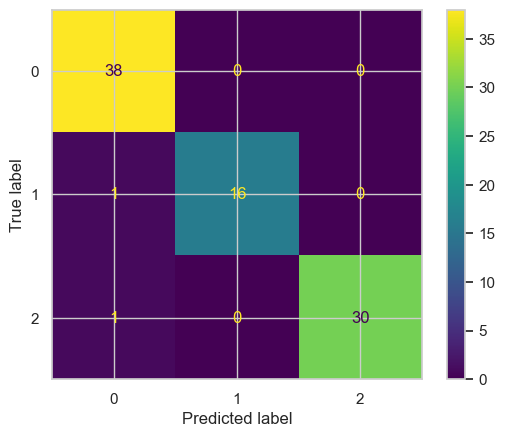

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test_dt2)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

# Check Feature Importance

In [76]:
dt1.feature_importances_

array([0.40154522, 0.52358735, 0.00914504, 0.02926414, 0.03645824,
       0.        , 0.        ])

In [77]:
pd.DataFrame(index=x.columns, data=dt1.feature_importances_, columns=['Feature Importance'])

,Feature Importance
Culmen Length (mm),0.401545
Culmen Depth (mm),0.523587
Flipper Length (mm),0.009145
Body Mass (g),0.029264
Island_Dream,0.036458
Island_Torgersen,0.000000
Sex_MALE,0.000000


In [78]:
pd.DataFrame(index=x.columns, data=dt2.feature_importances_, columns=['Feature Importance'])

,Feature Importance
Culmen Length (mm),0.367986
Culmen Depth (mm),0.547347
Flipper Length (mm),0.024864
Body Mass (g),0.008310
Island_Dream,0.051494
Island_Torgersen,0.000000
Sex_MALE,0.000000


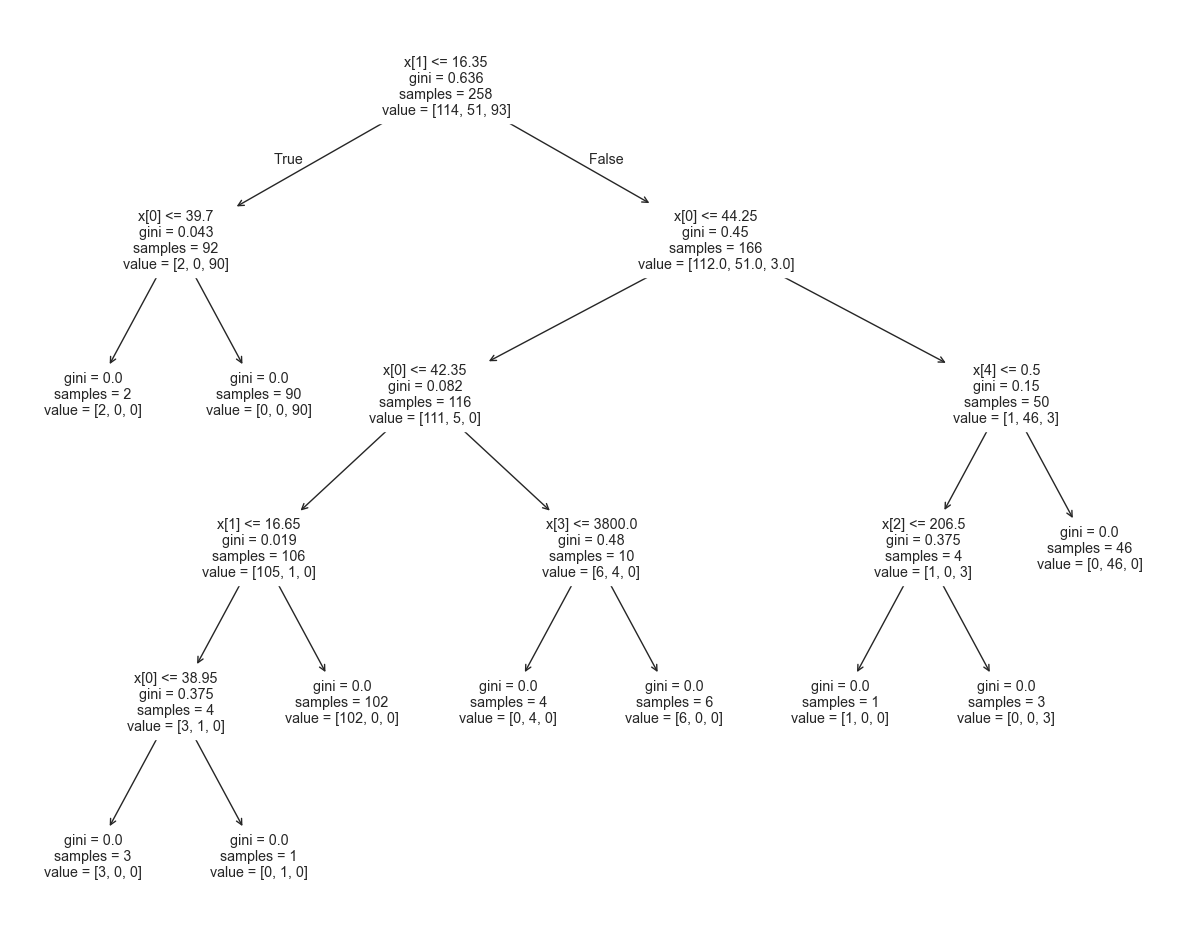

In [79]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,12))
plot_tree(dt1)
plt.show()

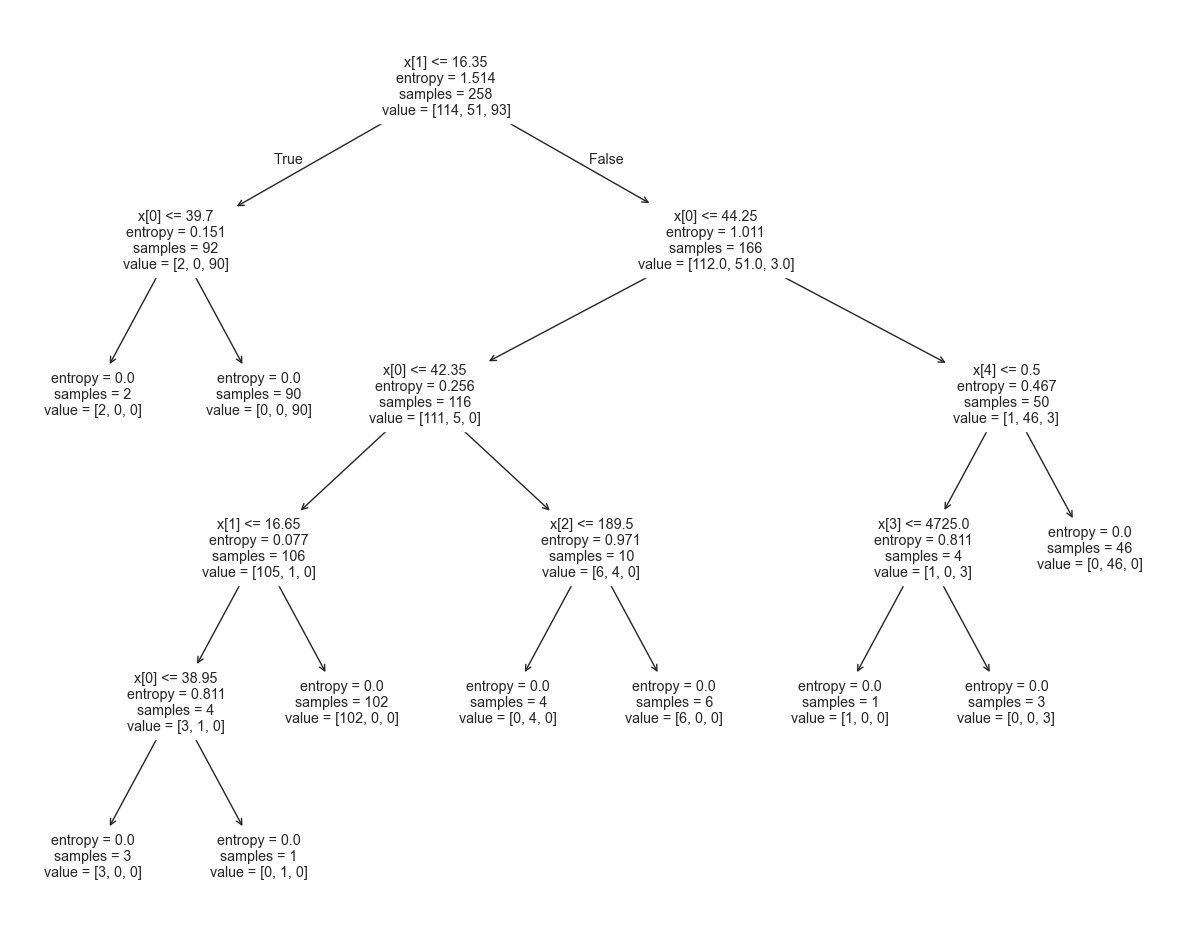

In [80]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,12))
plot_tree(dt2)
plt.show()

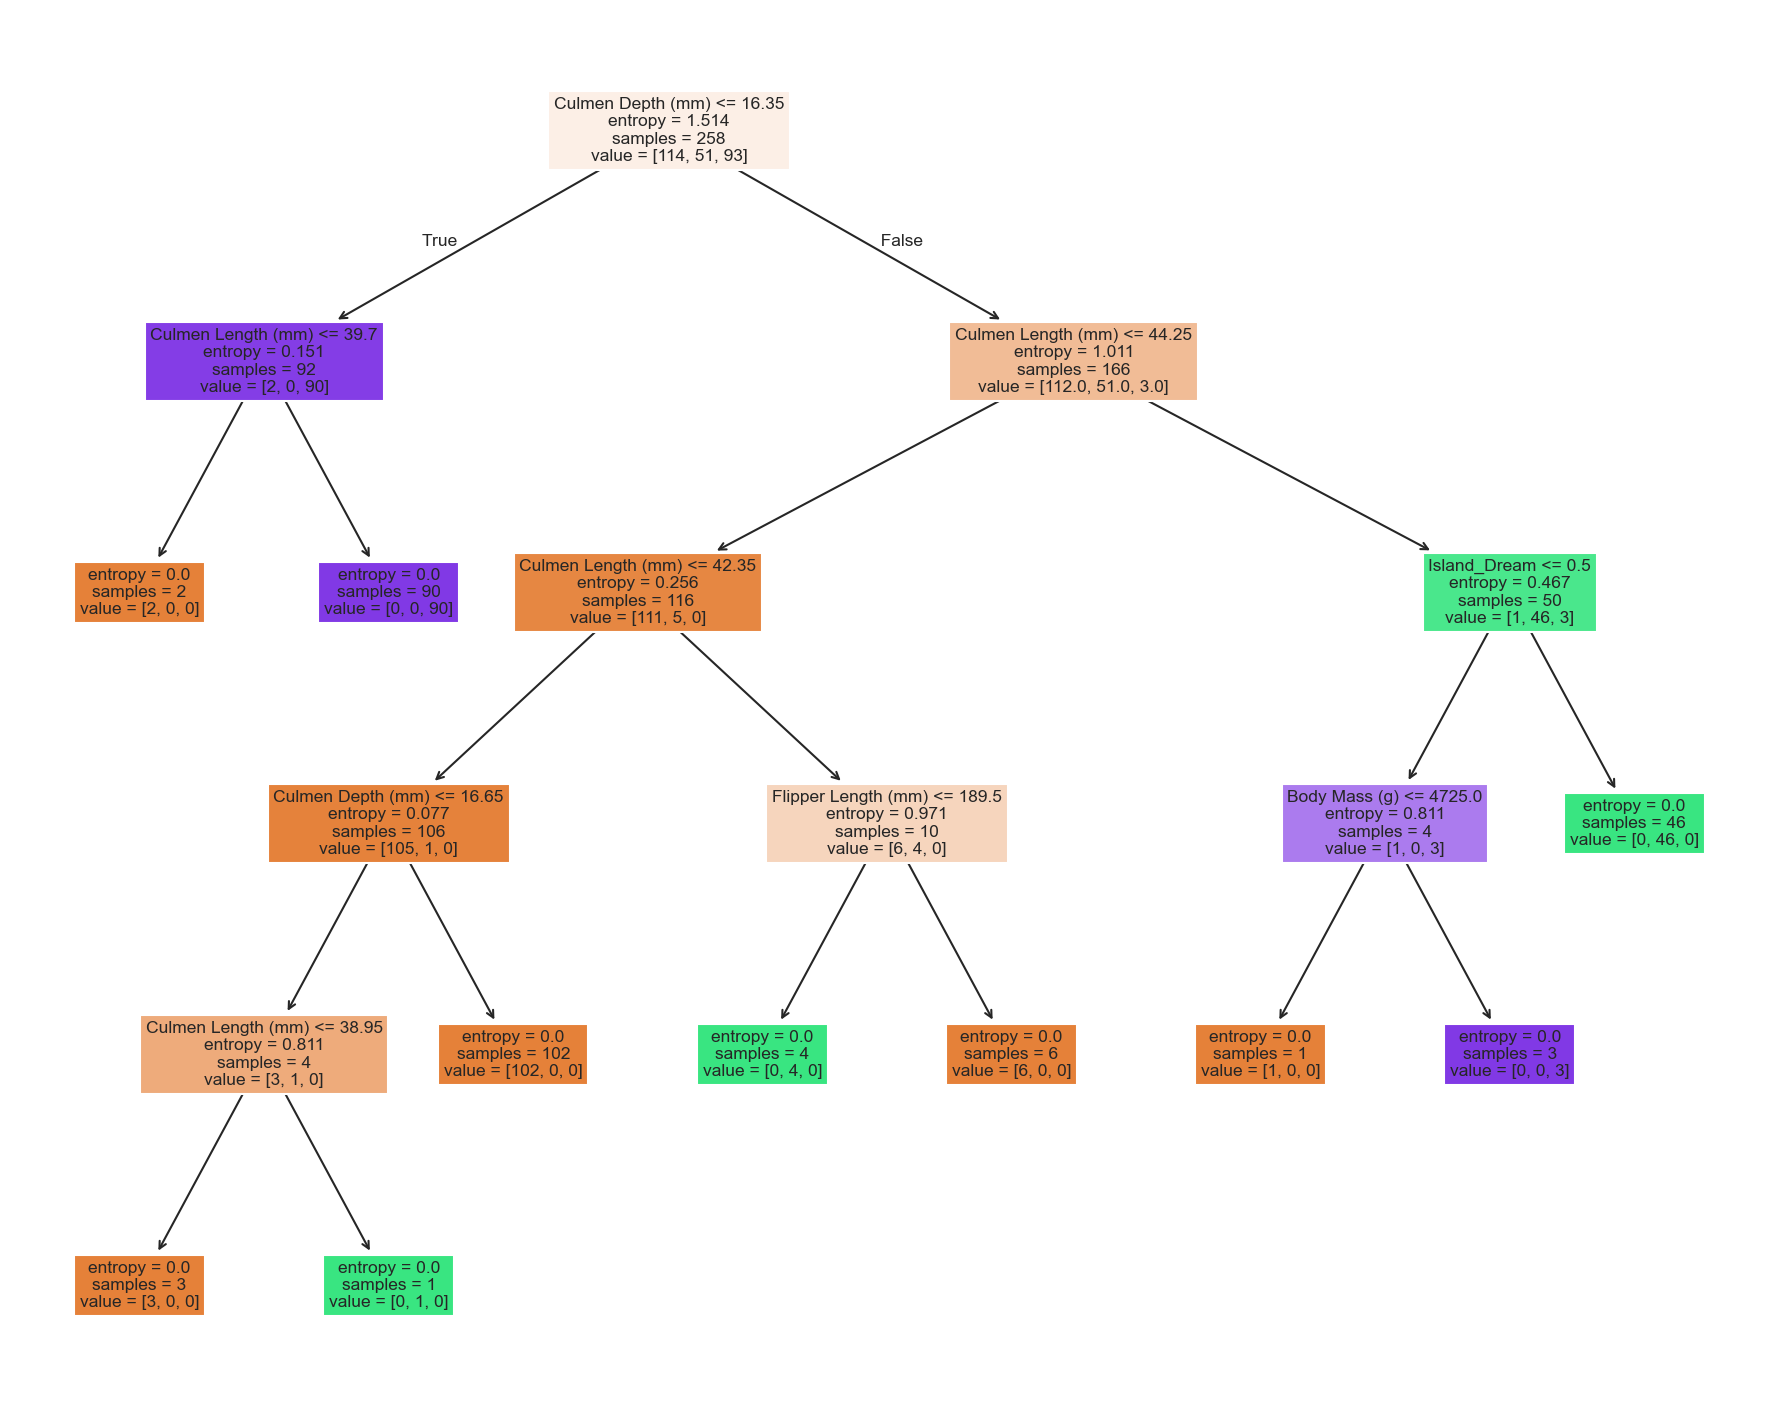

In [81]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,12), dpi=150)
plot_tree(dt2, filled=True, feature_names = x.columns)
plt.show()

# Using Post-Prunning Method to handle overfitting problem

In [82]:

def report_model(model):
    model_preds = model.predict(x_test)
    print(classification_report(y_test, model_preds))
    print('\n')
    plt.figure(figsize=(15,12), dpi=150)
    plot_tree(model, filled=True, feature_names=x.columns)

# prunned_dtree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3)

In [83]:

prunned_dtree = DecisionTreeClassifier(max_depth=3)
prunned_dtree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

           0       0.95      0.95      0.95        38
           1       1.00      0.94      0.97        17
           2       0.94      0.97      0.95        31

    accuracy                           0.95        86
   macro avg       0.96      0.95      0.96        86
weighted avg       0.95      0.95      0.95        86





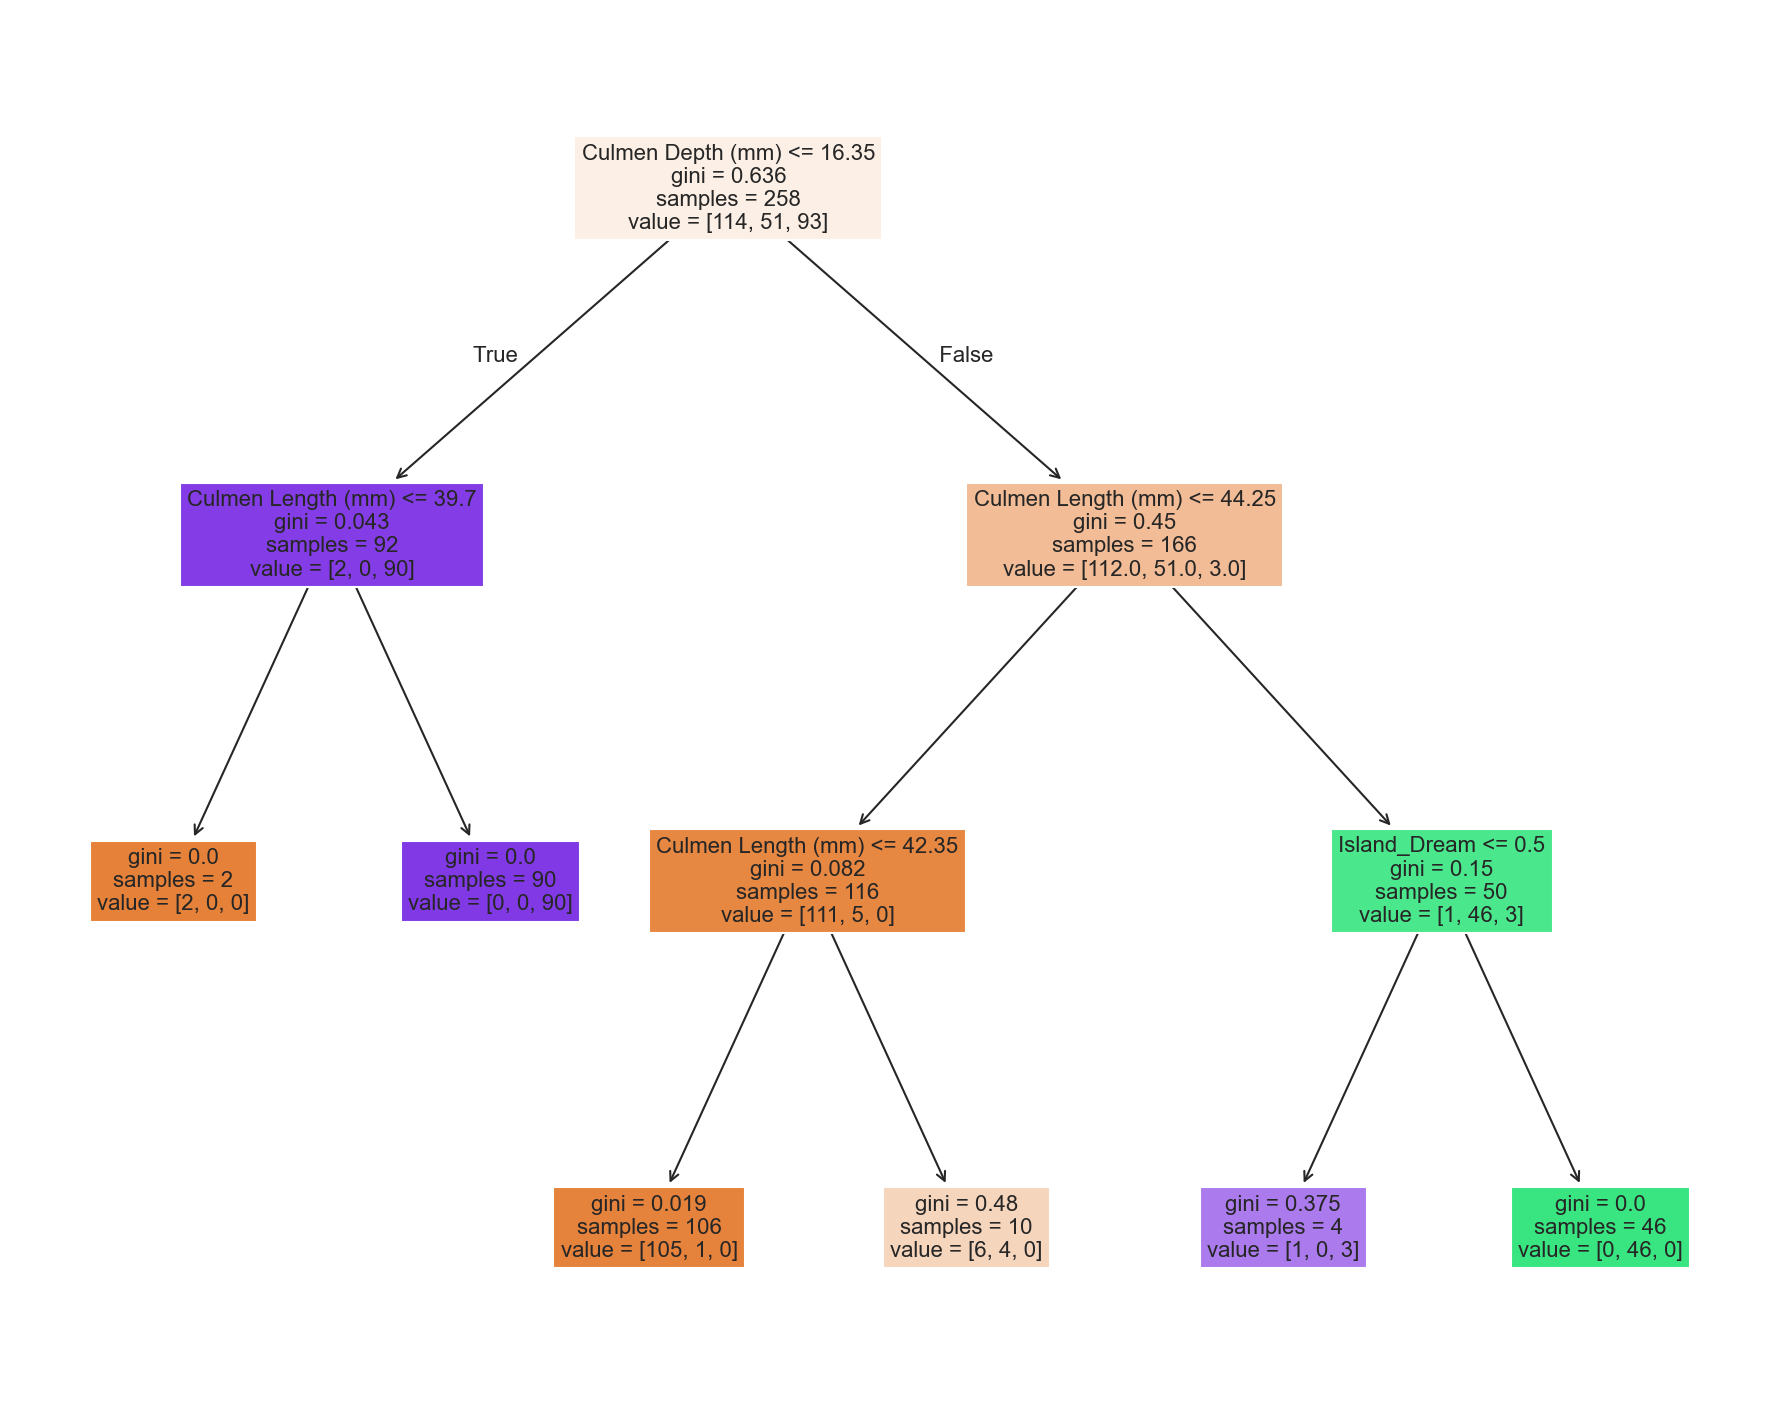

In [84]:
report_model(prunned_dtree)

In [85]:
y_pred_prunned_train = prunned_dtree.predict(x_train)
y_pred_prunned_test = prunned_dtree.predict(x_test)

In [86]:
print(accuracy_score(y_train, y_pred_prunned_train))
print()
print(accuracy_score(y_test, y_pred_prunned_test))

0.9767441860465116

0.9534883720930233


In [87]:
# Cross Validation approach
from sklearn.model_selection import cross_val_score
training_accuracy = cross_val_score(prunned_dtree, x_train, y_train, cv=10)

print(training_accuracy.mean())


0.960923076923077


In [88]:
# Cross Validation approach
from sklearn.model_selection import cross_val_score
training_accuracy = cross_val_score(dt1, x_train, y_train, cv=10)

print(training_accuracy.mean())

0.9690769230769231


In [95]:
# Cross Validation approach
from sklearn.model_selection import cross_val_score
training_accuracy = cross_val_score(dt2, x_train, y_train, cv=10)

print(training_accuracy.mean())

0.9690769230769231


In [89]:
print(dt1.get_depth())
print(dt2.get_depth())
print(prunned_dtree.get_depth())

5
5
3


# Visualization of boundaries

In [96]:
X = df[['Culmen Length (mm)', 'Culmen Depth (mm)']]
y = df['Species']

In [105]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [106]:
import numpy as np

x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

In [107]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

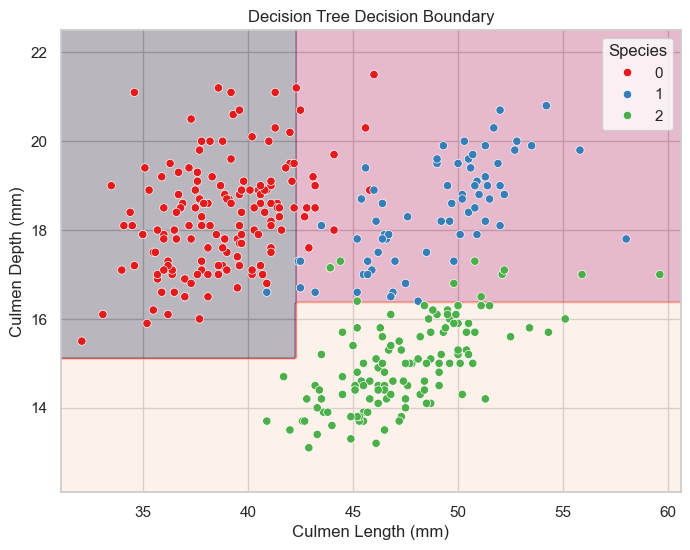

In [108]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

sns.scatterplot(
    x=X.iloc[:,0],
    y=X.iloc[:,1],
    hue=y,
    palette='Set1'
)

plt.xlabel("Culmen Length (mm)")
plt.ylabel("Culmen Depth (mm)")
plt.title("Decision Tree Decision Boundary")

plt.show()